## 1. Dataset Inspection

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail/retail_sales_dataset.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (1000, 12)

Columns: ['Transaction ID', 'Date', 'Customer_ID', 'Gender', 'Age', 'Product_Category', 'Quantity', 'Price_per_Unit', 'Total_Amount', 'Month', 'Month_Name', 'Day_of_Week']

Data types:
Transaction ID      int64
Date                  str
Customer_ID           str
Gender                str
Age                 int64
Product_Category      str
Quantity            int64
Price_per_Unit      int64
Total_Amount        int64
Month                 str
Month_Name            str
Day_of_Week           str
dtype: object

Missing values:
Transaction ID      0
Date                0
Customer_ID         0
Gender              0
Age                 0
Product_Category    0
Quantity            0
Price_per_Unit      0
Total_Amount        0
Month               0
Month_Name          0
Day_of_Week         0
dtype: int64

Duplicate rows: 0


## 2. Data Cleaning

In [24]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for col in ["Age","Quantity","Price_per_Unit","Total_Amount"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.drop_duplicates()
for col in ["Age","Quantity","Price_per_Unit","Total_Amount"]:
    df[col] = df[col].fillna(df[col].median())
for col in ["Gender","Product_Category"]:
    df[col] = df[col].fillna(df[col].mode().iloc[0])
df = df.dropna(subset=["Date"])

print("Missing values after cleaning:")
print(df.isnull().sum())
print("Duplicate rows after cleaning:", df.duplicated().sum())


Missing values after cleaning:
Transaction ID      0
Date                0
Customer_ID         0
Gender              0
Age                 0
Product_Category    0
Quantity            0
Price_per_Unit      0
Total_Amount        0
Month               0
Month_Name          0
Day_of_Week         0
dtype: int64
Duplicate rows after cleaning: 0


## 3. Mean, Median, Mode and Standard Deviation

In [25]:
numeric_cols = ["Age","Quantity","Price_per_Unit","Total_Amount"]
display(df[numeric_cols].describe())
print("Mean:\n", df[numeric_cols].mean())
print("\nMedian:\n", df[numeric_cols].median())
print("\nMode:\n", df[numeric_cols].mode().iloc[0])
print("\nStandard deviation:\n", df[numeric_cols].std())


,Age,Quantity,Price_per_Unit,Total_Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


Mean:
 Age                41.392
Quantity            2.514
Price_per_Unit    179.890
Total_Amount      456.000
dtype: float64

Median:
 Age                42.0
Quantity            3.0
Price_per_Unit     50.0
Total_Amount      135.0
dtype: float64

Mode:
 Age               43.0
Quantity           4.0
Price_per_Unit    50.0
Total_Amount      50.0
Name: 0, dtype: float64

Standard deviation:
 Age                13.681430
Quantity            1.132734
Price_per_Unit    189.681356
Total_Amount      559.997632
dtype: float64


## 4. Monthly Sales Trend

In [26]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Month")["Total_Amount"].sum()
monthly_sales


Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Name: Total_Amount, dtype: int64

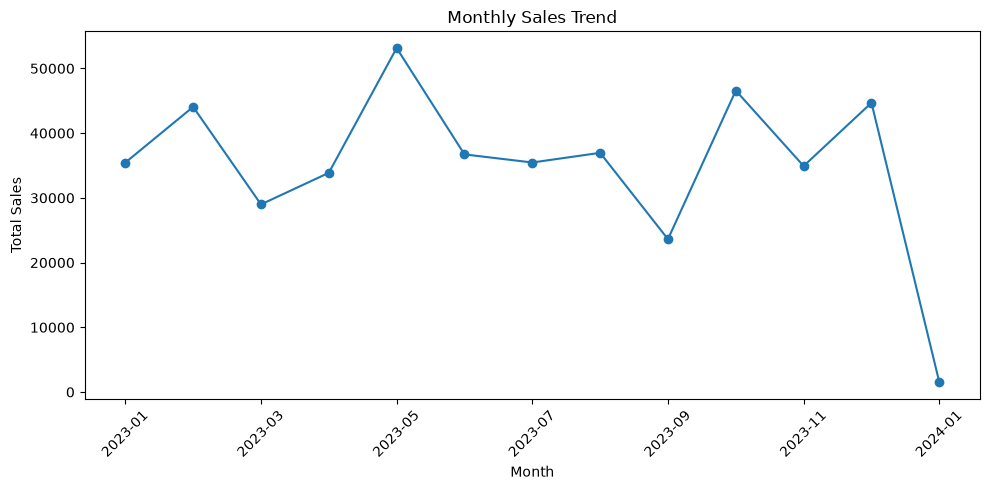

In [27]:
plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month"); plt.ylabel("Total Sales")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


**Observation:** The highest monthly sales occur in **2023-05** and the lowest in **2024-01**. Monthly monitoring can support inventory and campaign planning.

## 5. Quarterly Sales Trend

In [28]:
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)
quarterly_sales = df.groupby("Quarter")["Total_Amount"].sum()
quarterly_sales


Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Name: Total_Amount, dtype: int64

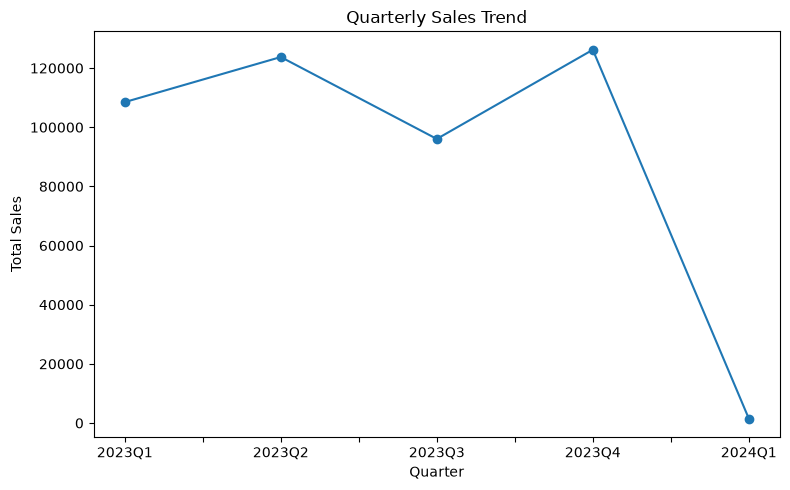

In [29]:
plt.figure(figsize=(8,5))
quarterly_sales.plot(marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter"); plt.ylabel("Total Sales")
plt.tight_layout(); plt.show()


**Observation:** The strongest quarter is **2023Q4** and the weakest is **2024Q1**. Quarterly aggregation gives a useful high-level view for business planning.

## 6. Customer Age-Group Distribution

In [30]:
age_bins = [0,17,25,35,45,55,65,np.inf]
age_labels = ["≤17","18–25","26–35","36–45","46–55","56–65","66+"]
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, include_lowest=True)
age_distribution = df["Age_Group"].value_counts().reindex(age_labels, fill_value=0)
age_distribution


Age_Group
≤17        0
18–25    169
26–35    205
36–45    202
46–55    229
56–65    195
66+        0
Name: count, dtype: int64

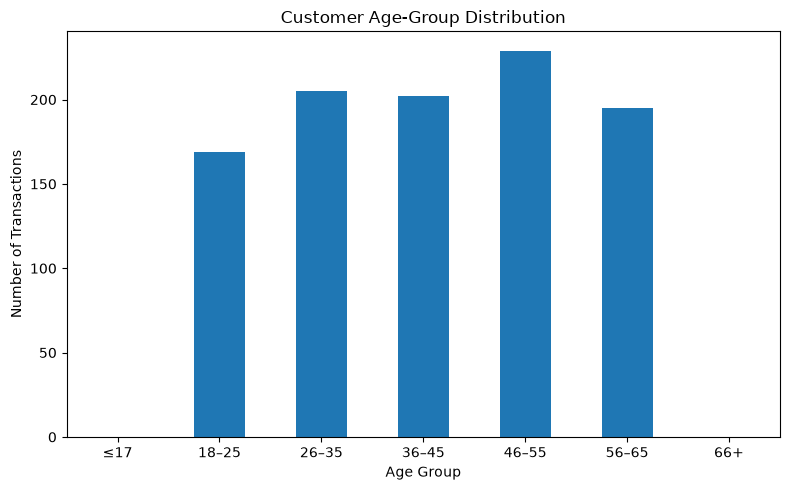

In [31]:
plt.figure(figsize=(8,5))
age_distribution.plot(kind="bar")
plt.title("Customer Age-Group Distribution")
plt.xlabel("Age Group"); plt.ylabel("Number of Transactions")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


**Observation:** **46–55** is the largest transaction-count age group. This identifies the most represented age segment, but does not by itself prove that it has the highest spending per customer.

## 7. Gender Breakdown

In [32]:
gender_sales = df.groupby("Gender")["Total_Amount"].sum().sort_values(ascending=False)
gender_sales


Gender
Female    232840
Male      223160
Name: Total_Amount, dtype: int64

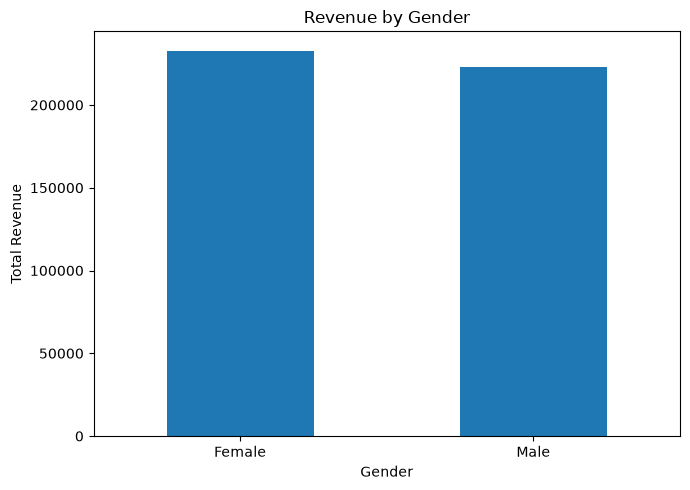

In [33]:
plt.figure(figsize=(7,5))
gender_sales.plot(kind="bar")
plt.title("Revenue by Gender")
plt.xlabel("Gender"); plt.ylabel("Total Revenue")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


**Observation:** **Female** contributes the highest total revenue. This is a descriptive result and should not be interpreted as proof that gender causes higher spending.

## 8. Revenue by Product Category

In [34]:
category_revenue = df.groupby("Product_Category")["Total_Amount"].sum().sort_values(ascending=False)
category_revenue


Product_Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total_Amount, dtype: int64

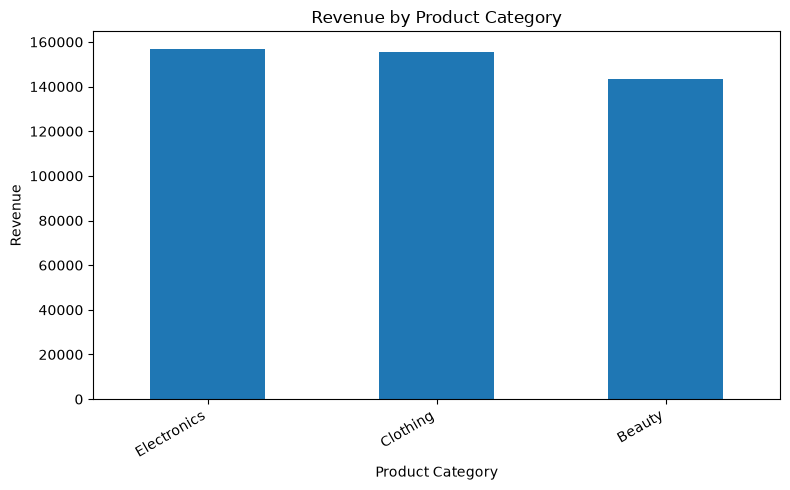

In [35]:
plt.figure(figsize=(8,5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category"); plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()


**Observation:** **Electronics** is the highest-revenue category. Inventory and promotional planning can prioritize strong categories while weaker categories can be investigated.

## 9. Top 10 Best-Selling Products — Dataset Limitation

The supplied dataset contains `Product_Category` but **does not contain individual product/item names**. Therefore, a genuine Top-10 product ranking cannot be calculated without inventing data. This project deliberately does not fabricate product names and instead performs the valid category-level analysis above.


## 10. Correlation Heatmap

In [36]:
corr = df[["Age","Quantity","Price_per_Unit","Total_Amount"]].corr()
corr


,Age,Quantity,Price_per_Unit,Total_Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price_per_Unit,-0.038423,0.017501,1.000000,0.851925
Total_Amount,-0.060568,0.373707,0.851925,1.000000


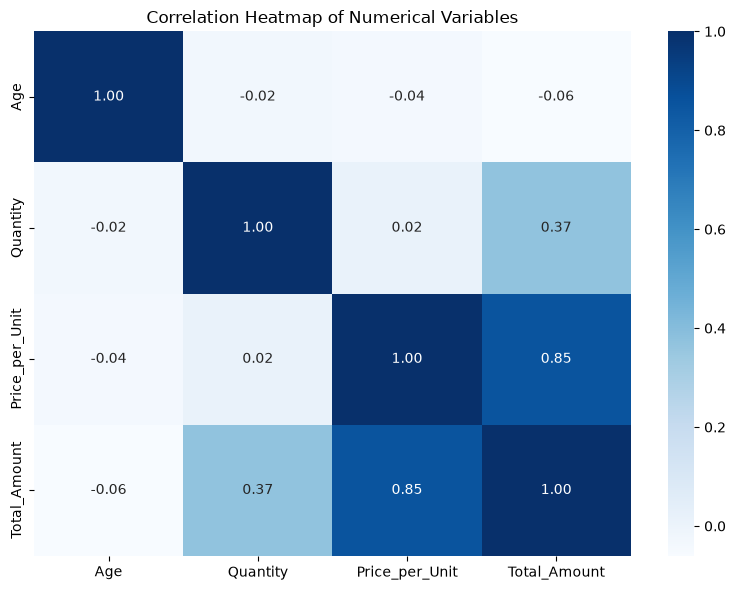

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout(); plt.show()


**Observation:** The heatmap summarizes linear relationships among the numerical variables. Correlation indicates association, not causation, so it should be interpreted together with the other analyses.

## 11. Additional Visualization

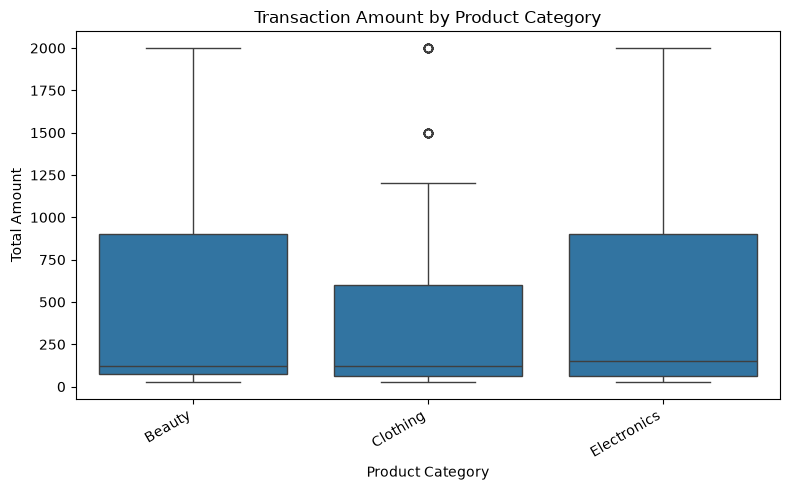

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Product_Category", y="Total_Amount")
plt.title("Transaction Amount by Product Category")
plt.xlabel("Product Category"); plt.ylabel("Total Amount")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
